# COVID-19 Economic Recovery Analysis

## 1. Problem Definition

This project analyses which countries recovered the fastest economically after the COVID-19 pandemic using GDP data. The target users are students and beginners who want to understand economic recovery trends through simple and interpretable data analysis.

## 2. Data Source

Source: World Bank (GDP, current US$)  
Period: 2019–2023  
Accessed: April 2026  

The dataset is sourced from the World Bank and processed for analysis. A cleaned dataset is included in the data/ folder for reproducibility.

## 3. Data Loading

In [1]:
import pandas as pd

df = pd.read_csv("data/world_bank_gdp.csv")

df

,Country Name,GDP_2019,GDP_2023
0,Brazil,1.873290e+12,2.191130e+12
1,Canada,1.743730e+12,2.173340e+12
2,China,1.456020e+13,1.827040e+13
3,Germany,3.959890e+12,4.562210e+12
4,France,2.722790e+12,3.056250e+12
5,UK,2.875710e+12,3.420800e+12
6,India,2.835610e+12,3.638490e+12
7,USA,2.138100e+13,2.729220e+13


## 4. Data Cleaning

In [2]:
# Rename columns
df.columns = ["Country", "GDP_2019", "GDP_2023"]

# Convert to trillion USD for readability
df["GDP_2019"] = df["GDP_2019"] / 1e12
df["GDP_2023"] = df["GDP_2023"] / 1e12

df

,Country,GDP_2019,GDP_2023
0,Brazil,1.87329,2.19113
1,Canada,1.74373,2.17334
2,China,14.56020,18.27040
3,Germany,3.95989,4.56221
4,France,2.72279,3.05625
5,UK,2.87571,3.42080
6,India,2.83561,3.63849
7,USA,21.38100,27.29220


GDP values are converted into trillion USD for better readability.

## 5. Analysis

In [3]:
# Calculate GDP growth rate
df["Growth_Rate"] = (df["GDP_2023"] - df["GDP_2019"]) / df["GDP_2019"]

df

,Country,GDP_2019,GDP_2023,Growth_Rate
0,Brazil,1.87329,2.19113,0.169669
1,Canada,1.74373,2.17334,0.246374
2,China,14.56020,18.27040,0.254818
3,Germany,3.95989,4.56221,0.152105
4,France,2.72279,3.05625,0.122470
5,UK,2.87571,3.42080,0.189550
6,India,2.83561,3.63849,0.283142
7,USA,21.38100,27.29220,0.276470


### Ranking Countries by Growth Rate

In [4]:
df_sorted = df.sort_values(by="Growth_Rate", ascending=False)

df_sorted

,Country,GDP_2019,GDP_2023,Growth_Rate
6,India,2.83561,3.63849,0.283142
7,USA,21.38100,27.29220,0.276470
2,China,14.56020,18.27040,0.254818
1,Canada,1.74373,2.17334,0.246374
5,UK,2.87571,3.42080,0.189550
0,Brazil,1.87329,2.19113,0.169669
3,Germany,3.95989,4.56221,0.152105
4,France,2.72279,3.05625,0.122470


Countries are ranked by GDP growth rate to identify which economies recovered faster after COVID-19.

## 6. Visualisation
### GDP Growth Rate Comparison (Bar Chart)

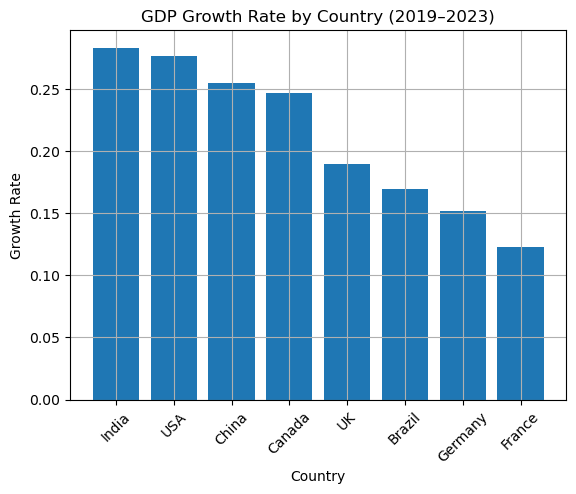

In [5]:
import matplotlib.pyplot as plt

plt.figure()

plt.bar(df_sorted["Country"], df_sorted["Growth_Rate"])

plt.title("GDP Growth Rate by Country (2019–2023)")
plt.xlabel("Country")
plt.ylabel("Growth Rate")

plt.xticks(rotation=45)
plt.grid()

plt.savefig("figures/bar_chart.png")

plt.show()

The bar chart compares GDP growth rates across countries.

### GDP Trend Over Time (Line Chart)

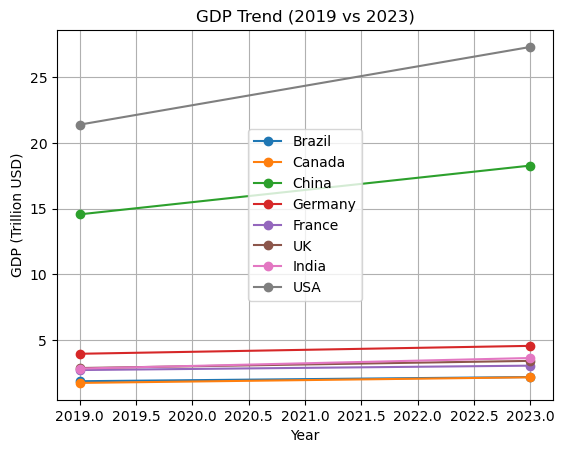

In [6]:
# Create trend dataset
df_trend = pd.DataFrame({
    "Country": df["Country"].tolist() * 2,
    "Year": [2019]*len(df) + [2023]*len(df),
    "GDP": df["GDP_2019"].tolist() + df["GDP_2023"].tolist()
})

plt.figure()

for country in df_trend["Country"].unique():
    subset = df_trend[df_trend["Country"] == country]
    plt.plot(subset["Year"], subset["GDP"], marker='o', label=country)

plt.title("GDP Trend (2019 vs 2023)")
plt.xlabel("Year")
plt.ylabel("GDP (Trillion USD)")
plt.legend()
plt.grid()

plt.savefig("figures/line_chart.png")

plt.show()

The line chart shows GDP changes between 2019 and 2023 for each country.

### Key Insight

Although the USA shows a larger absolute increase in GDP, its growth rate is not necessarily the highest compared to all countries. This is because the USA starts from a much larger economic base, while smaller economies can achieve higher percentage growth more easily.

In addition, this analysis is based on nominal GDP (current US$), which may be affected by inflation and exchange rate changes. Therefore, the results mainly reflect changes in nominal economic size and should be considered alongside other indicators when evaluating overall economic recovery.

## 7. Conclusion

All selected countries show economic recovery after COVID-19. Emerging economies such as India and China demonstrate higher growth rates, while developed economies such as the USA and Germany show more stable but slower growth.

The analysis suggests that economic structure and development stage may influence recovery patterns. However, the dataset is limited and simplified, so results should be interpreted with caution.